
# GVH Diagonal Cubic 0.2.14 — ADM Metric–Tensor Coupling
## Décomposition \(3+1\), couplage métrique–directionnel et contraintes ADM

**Auteur : Charlemagne O Laurince**

---

## Objectif

Les versions précédentes ont établi :

\[
\bar D_{\mu\nu}
\longrightarrow
\mathcal L_D
\longrightarrow
H_D
\longrightarrow
N_{\mathrm{DOF}}^{\mathrm{réduit}}=5.
\]

Cette version introduit le premier couplage explicite entre :

- la métrique gravitationnelle \(g_{\mu\nu}\) ;
- sa décomposition ADM ;
- le champ directionnel \(D_{\mu\nu}\).

La chaîne étudiée est :

\[
g_{\mu\nu},D_{\mu\nu}
\longrightarrow
(N,N^i,\gamma_{ij})
\longrightarrow
(K_{ij},{}^{(3)}R)
\longrightarrow
S_{\mathrm{ADM}}+S_D
\longrightarrow
\mathcal H,\mathcal H_i.
\]

---

## Statut scientifique

Le notebook construit une **action ADM candidate minimale**.

Il ne représente pas encore la décomposition \(3+1\) d'une action covariante GVH définitivement dérivée.

Le comptage des degrés de liberté obtenu ici reste donc provisoire et dépend des hypothèses suivantes :

1. \(\bar D_{ij}\) est spatial, symétrique et sans trace ;
2. le lapse et le shift ne possèdent pas de vitesses ;
3. la cinétique directionnelle est quadratique ;
4. les couplages aux courbures restent minimaux ou perturbatifs.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Décomposition ADM de la métrique

La métrique s'écrit :

\[
ds^2
=
-N^2dt^2
+
\gamma_{ij}
\left(dx^i+N^idt\right)
\left(dx^j+N^jdt\right).
\]

Les composantes sont :

\[
g_{00}
=
-N^2+N_iN^i,
\]

\[
g_{0i}=N_i,
\]

\[
g_{ij}=\gamma_{ij}.
\]

L'inverse est :

\[
g^{00}=-\frac1{N^2},
\]

\[
g^{0i}=\frac{N^i}{N^2},
\]

\[
g^{ij}
=
\gamma^{ij}
-
\frac{N^iN^j}{N^2}.
\]


In [2]:

N = sp.symbols("N", positive=True, real=True)

N1, N2, N3 = sp.symbols(
    "N1 N2 N3",
    real=True
)

g11, g22, g33 = sp.symbols(
    "gamma11 gamma22 gamma33",
    positive=True,
    real=True
)

gamma = sp.diag(g11, g22, g33)
gamma_inv = sp.simplify(gamma.inv())

shift_up = sp.Matrix([N1, N2, N3])
shift_down = sp.simplify(gamma*shift_up)

g4 = sp.zeros(4)

g4[0,0] = sp.simplify(
    -N**2 + (shift_up.T*gamma*shift_up)[0]
)

for i in range(3):
    g4[0,i+1] = shift_down[i]
    g4[i+1,0] = shift_down[i]

for i in range(3):
    for j in range(3):
        g4[i+1,j+1] = gamma[i,j]

print("Métrique ADM :")
display(g4)

print("Déterminant :")
display(sp.factor(g4.det()))


Métrique ADM :


⎡   2     2         2         2                            ⎤
⎢- N  + N₁ ⋅γ₁₁ + N₂ ⋅γ₂₂ + N₃ ⋅γ₃₃  N₁⋅γ₁₁  N₂⋅γ₂₂  N₃⋅γ₃₃⎥
⎢                                                          ⎥
⎢              N₁⋅γ₁₁                 γ₁₁      0       0   ⎥
⎢                                                          ⎥
⎢              N₂⋅γ₂₂                  0      γ₂₂      0   ⎥
⎢                                                          ⎥
⎣              N₃⋅γ₃₃                  0       0      γ₃₃  ⎦

Déterminant :


  2            
-N ⋅γ₁₁⋅γ₂₂⋅γ₃₃


# 2. Vérification de l'inverse ADM

La relation fondamentale est :

\[
g_{\mu\alpha}g^{\alpha\nu}
=
\delta_\mu{}^\nu.
\]


In [3]:

g4_inv_expected = sp.zeros(4)

g4_inv_expected[0,0] = -1/N**2

for i in range(3):
    g4_inv_expected[0,i+1] = shift_up[i]/N**2
    g4_inv_expected[i+1,0] = shift_up[i]/N**2

for i in range(3):
    for j in range(3):
        g4_inv_expected[i+1,j+1] = (
            gamma_inv[i,j]
            - shift_up[i]*shift_up[j]/N**2
        )

inverse_residual = sp.simplify(
    g4*g4_inv_expected-sp.eye(4)
)

display(g4_inv_expected)
print("Résidu de l'inverse :")
display(inverse_residual)


⎡-1      N₁         N₂         N₃    ⎤
⎢───     ──         ──         ──    ⎥
⎢ 2       2          2          2    ⎥
⎢N       N          N          N     ⎥
⎢                                    ⎥
⎢             2                      ⎥
⎢N₁    1    N₁    -N₁⋅N₂     -N₁⋅N₃  ⎥
⎢──   ─── - ───   ───────    ─────── ⎥
⎢ 2   γ₁₁    2       2          2    ⎥
⎢N          N       N          N     ⎥
⎢                                    ⎥
⎢                        2           ⎥
⎢N₂    -N₁⋅N₂     1    N₂    -N₂⋅N₃  ⎥
⎢──    ───────   ─── - ───   ─────── ⎥
⎢ 2       2      γ₂₂    2       2    ⎥
⎢N       N             N       N     ⎥
⎢                                    ⎥
⎢                                   2⎥
⎢N₃    -N₁⋅N₃     -N₂⋅N₃     1    N₃ ⎥
⎢──    ───────    ───────   ─── - ───⎥
⎢ 2       2          2      γ₃₃    2 ⎥
⎣N       N          N             N  ⎦

Résidu de l'inverse :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 3. Normale à l'hypersurface spatiale

La normale temporelle unitaire est :

\[
n_\mu=(-N,0,0,0),
\]

\[
n^\mu
=
\left(
\frac1N,
-\frac{N^i}{N}
\right).
\]

Elle satisfait :

\[
n^\mu n_\mu=-1.
\]

Le projecteur spatial est :

\[
\gamma_{\mu\nu}
=
g_{\mu\nu}
+
n_\mu n_\nu.
\]


In [4]:

n_cov = sp.Matrix([-N, 0, 0, 0])
n_up = sp.simplify(g4_inv_expected*n_cov)

normal_norm = sp.simplify(
    (n_cov.T*n_up)[0]
)

projector4 = sp.simplify(
    g4 + n_cov*n_cov.T
)

print("n^mu =")
display(n_up)

print("n_mu n^mu =")
display(normal_norm)

print("Projecteur spatial 4D :")
display(projector4)


n^mu =


⎡ 1  ⎤
⎢ ─  ⎥
⎢ N  ⎥
⎢    ⎥
⎢-N₁ ⎥
⎢────⎥
⎢ N  ⎥
⎢    ⎥
⎢-N₂ ⎥
⎢────⎥
⎢ N  ⎥
⎢    ⎥
⎢-N₃ ⎥
⎢────⎥
⎣ N  ⎦

n_mu n^mu =


-1

Projecteur spatial 4D :


⎡  2         2         2                            ⎤
⎢N₁ ⋅γ₁₁ + N₂ ⋅γ₂₂ + N₃ ⋅γ₃₃  N₁⋅γ₁₁  N₂⋅γ₂₂  N₃⋅γ₃₃⎥
⎢                                                   ⎥
⎢          N₁⋅γ₁₁              γ₁₁      0       0   ⎥
⎢                                                   ⎥
⎢          N₂⋅γ₂₂               0      γ₂₂      0   ⎥
⎢                                                   ⎥
⎣          N₃⋅γ₃₃               0       0      γ₃₃  ⎦


# 4. Courbure extrinsèque

La courbure extrinsèque est :

\[
K_{ij}
=
\frac{1}{2N}
\left(
\dot\gamma_{ij}
-
D_iN_j
-
D_jN_i
\right).
\]

Dans une réduction homogène avec shift nul :

\[
K_{ij}
=
\frac{\dot\gamma_{ij}}{2N}.
\]

Sa trace est :

\[
K=\gamma^{ij}K_{ij}.
\]


In [5]:

t = sp.symbols("t", real=True)

a1 = sp.Function("a1")(t)
a2 = sp.Function("a2")(t)
a3 = sp.Function("a3")(t)
N_t = sp.Function("N")(t)

gamma_hom = sp.diag(
    a1**2,
    a2**2,
    a3**2
)

gamma_hom_inv = sp.simplify(
    gamma_hom.inv()
)

Kij = sp.simplify(
    sp.diff(gamma_hom,t)/(2*N_t)
)

K_trace = sp.simplify(
    sum(
        gamma_hom_inv[i,j]*Kij[i,j]
        for i in range(3)
        for j in range(3)
    )
)

KijKij = sp.simplify(
    sum(
        gamma_hom_inv[i,k]
        * gamma_hom_inv[j,l]
        * Kij[i,j]
        * Kij[k,l]
        for i in range(3)
        for j in range(3)
        for k in range(3)
        for l in range(3)
    )
)

print("K_ij =")
display(Kij)

print("K =")
display(K_trace)

print("K_ij K^ij =")
display(KijKij)


K_ij =


⎡      d                                          ⎤
⎢a₁(t)⋅──(a₁(t))                                  ⎥
⎢      dt                                         ⎥
⎢───────────────         0                0       ⎥
⎢     N(t)                                        ⎥
⎢                                                 ⎥
⎢                       d                         ⎥
⎢                 a₂(t)⋅──(a₂(t))                 ⎥
⎢                       dt                        ⎥
⎢       0         ───────────────         0       ⎥
⎢                      N(t)                       ⎥
⎢                                                 ⎥
⎢                                        d        ⎥
⎢                                  a₃(t)⋅──(a₃(t))⎥
⎢                                        dt       ⎥
⎢       0                0         ───────────────⎥
⎣                                       N(t)      ⎦

K =


d            d            d         
──(a₃(t))    ──(a₂(t))    ──(a₁(t)) 
dt           dt           dt        
────────── + ────────── + ──────────
N(t)⋅a₃(t)   N(t)⋅a₂(t)   N(t)⋅a₁(t)

K_ij K^ij =


           2              2              2
⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞ 
⎜──(a₃(t))⎟    ⎜──(a₂(t))⎟    ⎜──(a₁(t))⎟ 
⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠ 
──────────── + ──────────── + ────────────
 2      2       2      2       2      2   
N (t)⋅a₃ (t)   N (t)⋅a₂ (t)   N (t)⋅a₁ (t)


# 5. Action gravitationnelle ADM

À une contribution de bord près, l'action d'Einstein–Hilbert devient :

\[
S_{\mathrm{GR}}
=
\frac{M_{\mathrm{Pl}}^2}{2}
\int dt\,d^3x\,
N\sqrt{\gamma}
\left[
{}^{(3)}R
+
K_{ij}K^{ij}
-
K^2
\right].
\]

Pour une réduction homogène plate :

\[
{}^{(3)}R=0.
\]


In [6]:

Mpl = sp.symbols(
    "Mpl",
    positive=True,
    real=True
)

sqrt_gamma = sp.simplify(
    sp.sqrt(gamma_hom.det())
)

L_GR_hom = sp.simplify(
    Mpl**2/2
    * N_t
    * sqrt_gamma
    * (KijKij-K_trace**2)
)

print("sqrt(gamma) =")
display(sqrt_gamma)

print("L_GR homogène =")
display(sp.factor(L_GR_hom))


sqrt(gamma) =


   ______________________
  ╱   2      2      2    
╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) 

L_GR homogène =


         ______________________                                                ↪
    2   ╱   2      2      2     ⎛      d         d                 d         d ↪
-Mpl ⋅╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅⎜a₁(t)⋅──(a₂(t))⋅──(a₃(t)) + a₂(t)⋅──(a₁(t))⋅─ ↪
                                ⎝      dt        dt                dt        d ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                               N(t)⋅a₁(t)⋅a₂(t)⋅a₃(t)          ↪

↪                                       
↪                  d         d        ⎞ 
↪ ─(a₃(t)) + a₃(t)⋅──(a₁(t))⋅──(a₂(t))⎟ 
↪ t                dt        dt       ⎠ 
↪ ──────────────────────────────────────
↪                                       


# 6. Limite isotrope FLRW

Pour :

\[
a_1=a_2=a_3=a,
\]

on doit retrouver :

\[
K_{ij}K^{ij}=3H_N^2,
\]

\[
K=3H_N,
\]

avec :

\[
H_N=\frac{\dot a}{Na}.
\]

Donc :

\[
K_{ij}K^{ij}-K^2=-6H_N^2.
\]


In [7]:

a = sp.Function("a")(t)

isotropic_subs = {
    a1: a,
    a2: a,
    a3: a,
    sp.diff(a1,t): sp.diff(a,t),
    sp.diff(a2,t): sp.diff(a,t),
    sp.diff(a3,t): sp.diff(a,t)
}

K_iso = sp.simplify(
    K_trace.subs(isotropic_subs)
)

K2_iso = sp.simplify(
    KijKij.subs(isotropic_subs)
)

L_GR_iso = sp.simplify(
    L_GR_hom.subs(isotropic_subs)
)

print("K isotrope =")
display(K_iso)

print("KijKij isotrope =")
display(K2_iso)

print("L_GR isotrope =")
display(sp.factor(L_GR_iso))


K isotrope =


  d       
3⋅──(a(t))
  dt      
──────────
N(t)⋅a(t) 

KijKij isotrope =


            2
  ⎛d       ⎞ 
3⋅⎜──(a(t))⎟ 
  ⎝dt      ⎠ 
─────────────
  2     2    
 N (t)⋅a (t) 

L_GR isotrope =


           _______           2 
      2   ╱  6     ⎛d       ⎞  
-3⋅Mpl ⋅╲╱  a (t) ⋅⎜──(a(t))⎟  
                   ⎝dt      ⎠  
───────────────────────────────
                2              
          N(t)⋅a (t)           


# 7. Décomposition \(3+1\) du tenseur \(D_{\mu\nu}\)

Un tenseur symétrique peut être décomposé en :

\[
D_{\mu\nu}
=
\Phi_D n_\mu n_\nu
+
2n_{(\mu}V_{\nu)}
+
S_{\mu\nu},
\]

avec :

\[
n^\mu V_\mu=0,
\]

\[
n^\mu S_{\mu\nu}=0.
\]

Le secteur retenu jusqu'ici est la partie spatiale, symétrique et sans trace :

\[
\bar D_{ij}
=
S_{ij}
-
\frac13\gamma_{ij}S,
\]

\[
S=\gamma^{ij}S_{ij}.
\]

Les composantes \(\Phi_D\) et \(V_i\) doivent être soit contraintes, soit dynamiques dans l'action complète.


In [8]:

decomposition_count = pd.DataFrame([
    {
        "sector": "Phi_D",
        "components": 1,
        "current_status": "not included / constraint candidate"
    },
    {
        "sector": "V_i",
        "components": 3,
        "current_status": "not included / constraint candidate"
    },
    {
        "sector": "spatial trace S",
        "components": 1,
        "current_status": "removed in traceless sector"
    },
    {
        "sector": "Dbar_ij",
        "components": 5,
        "current_status": "dynamical reduced sector"
    }
])

decomposition_count


,sector,components,current_status
0,Phi_D,1,not included / constraint candidate
1,V_i,3,not included / constraint candidate
2,spatial trace S,1,removed in traceless sector
3,Dbar_ij,5,dynamical reduced sector



# 8. Paramétrisation homogène de \(\bar D_{ij}\)

Nous utilisons cinq fonctions :

\[
q_A(t),
\qquad A=1,\dots,5.
\]

Dans une base orthonormée locale, la matrice sans trace est :

\[
\bar D_{\hat i\hat j}
=
\begin{pmatrix}
q_1+q_2/\sqrt3&q_3&q_4\\
q_3&-q_1+q_2/\sqrt3&q_5\\
q_4&q_5&-2q_2/\sqrt3
\end{pmatrix}.
\]

Pour le minisuperspace, cette base orthonormée évite de confondre les amplitudes physiques avec les facteurs d'échelle coordonnés.


In [9]:

q = [
    sp.Function(f"q{i}")(t)
    for i in range(1,6)
]

sqrt3 = sp.sqrt(3)

Dbar_orth = sp.Matrix([
    [q[0]+q[1]/sqrt3, q[2], q[3]],
    [q[2], -q[0]+q[1]/sqrt3, q[4]],
    [q[3], q[4], -2*q[1]/sqrt3]
])

Dbar_norm = sp.simplify(
    sp.trace(Dbar_orth*Dbar_orth)
)

Dbar_dot_norm = sp.simplify(
    sp.trace(
        sp.diff(Dbar_orth,t)
        * sp.diff(Dbar_orth,t)
    )
)

print("Trace :")
display(sp.simplify(sp.trace(Dbar_orth)))

print("Norme :")
display(sp.factor(Dbar_norm))

print("Norme cinétique :")
display(sp.factor(Dbar_dot_norm))


Trace :


0

Norme :


  ⎛  2        2        2        2        2   ⎞
2⋅⎝q₁ (t) + q₂ (t) + q₃ (t) + q₄ (t) + q₅ (t)⎠

Norme cinétique :


  ⎛           2              2              2              2              2⎞
  ⎜⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞ ⎟
2⋅⎜⎜──(q₁(t))⎟  + ⎜──(q₂(t))⎟  + ⎜──(q₃(t))⎟  + ⎜──(q₄(t))⎟  + ⎜──(q₅(t))⎟ ⎟
  ⎝⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠ ⎠


# 9. Action ADM candidate du secteur directionnel

Une forme minimale homogène est :

\[
S_D
=
\int dt\,d^3x\,
N\sqrt{\gamma}
\left[
\frac{K_D}{2N^2}
\dot{\bar D}_{\hat i\hat j}
\dot{\bar D}^{\hat i\hat j}
-
\frac{m_D^2}{2}
\bar D_{\hat i\hat j}
\bar D^{\hat i\hat j}
\right].
\]

Dans une théorie non homogène, il faudra ajouter :

\[
-\frac{G_D}{2}
D_k\bar D_{ij}D^k\bar D^{ij}.
\]


In [10]:

K_D, m_D = sp.symbols(
    "K_D m_D",
    real=True
)

L_D_hom = sp.simplify(
    N_t*sqrt_gamma
    * (
        K_D/(2*N_t**2)*Dbar_dot_norm
        - m_D**2/2*Dbar_norm
    )
)

print("L_D homogène =")
display(sp.factor(L_D_hom))


L_D homogène =


   ______________________ ⎛               2                  2                 ↪
  ╱   2      2      2     ⎜    ⎛d        ⎞        ⎛d        ⎞        ⎛d        ↪
╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅⎜K_D⋅⎜──(q₁(t))⎟  + K_D⋅⎜──(q₂(t))⎟  + K_D⋅⎜──(q₃(t) ↪
                          ⎝    ⎝dt       ⎠        ⎝dt       ⎠        ⎝dt       ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪   2                  2                  2                                    ↪
↪  ⎞        ⎛d        ⎞        ⎛d        ⎞       2  2      2         2  2      ↪
↪ )⎟  + K_D⋅⎜──(q₄(t))⎟  + K_D⋅⎜──(q₅(t))⎟  - m_D ⋅N (t)⋅q₁ (t) - m_D ⋅N (t)⋅q ↪
↪  ⎠        ⎝dt       ⎠        ⎝dt       ⎠                                     ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                               N(t)                                           ↪

↪                         


# 10. Couplage minimal métrique–directionnel

L'action réduite totale est :

\[
L_{\mathrm{tot}}
=
L_{\mathrm{GR}}
+
L_D.
\]

Le couplage minimal apparaît déjà par :

- le facteur \(N\sqrt{\gamma}\) ;
- la conversion entre temps coordonné et temps propre ;
- l'évolution des facteurs d'échelle ;
- la contrainte hamiltonienne commune.

Aucun terme direct comme \(D_{\mu\nu}R^{\mu\nu}\) n'est encore ajouté.


In [11]:

L_total = sp.simplify(
    L_GR_hom + L_D_hom
)

print("Lagrangien total homogène :")
display(sp.factor(L_total))


Lagrangien total homogène :


    ______________________ ⎛                                   2               ↪
   ╱   2      2      2     ⎜                        ⎛d        ⎞                ↪
-╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅⎜- K_D⋅a₁(t)⋅a₂(t)⋅a₃(t)⋅⎜──(q₁(t))⎟  - K_D⋅a₁(t)⋅a ↪
                           ⎝                        ⎝dt       ⎠                ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪                       2                                    2                 ↪
↪            ⎛d        ⎞                          ⎛d        ⎞                  ↪
↪ ₂(t)⋅a₃(t)⋅⎜──(q₂(t))⎟  - K_D⋅a₁(t)⋅a₂(t)⋅a₃(t)⋅⎜──(q₃(t))⎟  - K_D⋅a₁(t)⋅a₂( ↪
↪            ⎝dt       ⎠                          ⎝dt       ⎠                  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪                     2   


# 11. Moments conjugués directionnels

Les moments des cinq modes sont :

\[
p_A
=
\frac{\partial L_{\mathrm{tot}}}
{\partial\dot q_A}.
\]

On attend une structure :

\[
p_A
\propto
\frac{\sqrt{\gamma}K_D}{N}\dot q_A.
\]

Si \(K_D\neq0\), les cinq vitesses sont inversibles.


In [12]:

qdot = [
    sp.diff(qi,t)
    for qi in q
]

p_q = [
    sp.simplify(
        sp.diff(L_total,vi)
    )
    for vi in qdot
]

for i, momentum in enumerate(p_q, start=1):
    print(f"p_q{i} =")
    display(sp.factor(momentum))


p_q1 =


         ______________________          
        ╱   2      2      2     d        
2⋅K_D⋅╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅──(q₁(t))
                                dt       
─────────────────────────────────────────
                  N(t)                   

p_q2 =


         ______________________          
        ╱   2      2      2     d        
2⋅K_D⋅╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅──(q₂(t))
                                dt       
─────────────────────────────────────────
                  N(t)                   

p_q3 =


         ______________________          
        ╱   2      2      2     d        
2⋅K_D⋅╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅──(q₃(t))
                                dt       
─────────────────────────────────────────
                  N(t)                   

p_q4 =


         ______________________          
        ╱   2      2      2     d        
2⋅K_D⋅╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅──(q₄(t))
                                dt       
─────────────────────────────────────────
                  N(t)                   

p_q5 =


         ______________________          
        ╱   2      2      2     d        
2⋅K_D⋅╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅──(q₅(t))
                                dt       
─────────────────────────────────────────
                  N(t)                   


# 12. Moment du lapse

Le lagrangien ne dépend pas de \(\dot N\).

Donc :

\[
p_N=0
\]

est une contrainte primaire.


In [13]:

Ndot = sp.diff(N_t,t)

p_N = sp.simplify(
    sp.diff(L_total,Ndot)
)

print("p_N =")
display(p_N)


p_N =


0


# 13. Contrainte hamiltonienne réduite

La variation par rapport au lapse impose :

\[
\frac{\partial L_{\mathrm{tot}}}{\partial N}=0.
\]

Cette équation contient simultanément :

- l'énergie gravitationnelle ;
- l'énergie cinétique directionnelle ;
- le potentiel directionnel.

Elle constitue l'analogue réduit de :

\[
\mathcal H_{\mathrm{GR}}
+
\mathcal H_D
\approx0.
\]


In [14]:

Hamiltonian_constraint_L = sp.simplify(
    sp.diff(L_total,N_t)
)

print("Contrainte issue du lapse :")
display(sp.factor(Hamiltonian_constraint_L))


Contrainte issue du lapse :


   ______________________ ⎛                                   2                ↪
  ╱   2      2      2     ⎜                        ⎛d        ⎞                 ↪
╲╱  a₁ (t)⋅a₂ (t)⋅a₃ (t) ⋅⎜- K_D⋅a₁(t)⋅a₂(t)⋅a₃(t)⋅⎜──(q₁(t))⎟  - K_D⋅a₁(t)⋅a₂ ↪
                          ⎝                        ⎝dt       ⎠                 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪                      2                                    2                  ↪
↪           ⎛d        ⎞                          ⎛d        ⎞                   ↪
↪ (t)⋅a₃(t)⋅⎜──(q₂(t))⎟  - K_D⋅a₁(t)⋅a₂(t)⋅a₃(t)⋅⎜──(q₃(t))⎟  - K_D⋅a₁(t)⋅a₂(t ↪
↪           ⎝dt       ⎠                          ⎝dt       ⎠                   ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                          


# 14. Limite isotrope métrique avec secteur directionnel

En posant :

\[
a_1=a_2=a_3=a,
\]

l'action devient :

\[
L_{\mathrm{tot}}^{\mathrm{iso}}
=
-\frac{3M_{\mathrm{Pl}}^2a\dot a^2}{N}
+
Na^3
\left[
\frac{K_D}{2N^2}
\dot{\bar D}^2
-
\frac{m_D^2}{2}\bar D^2
\right],
\]

à une normalisation de la base des cinq modes près.


In [15]:

L_total_iso = sp.simplify(
    L_total.subs(isotropic_subs)
)

constraint_iso = sp.simplify(
    sp.diff(L_total_iso,N_t)
)

print("Lagrangien isotrope couplé :")
display(sp.factor(L_total_iso))

print("Contrainte isotrope :")
display(sp.factor(constraint_iso))


Lagrangien isotrope couplé :


 ⎛                       2                        2                        2   ↪
 ⎜       2    ⎛d        ⎞         2    ⎛d        ⎞         2    ⎛d        ⎞    ↪
-⎜- K_D⋅a (t)⋅⎜──(q₁(t))⎟  - K_D⋅a (t)⋅⎜──(q₂(t))⎟  - K_D⋅a (t)⋅⎜──(q₃(t))⎟  - ↪
 ⎝            ⎝dt       ⎠              ⎝dt       ⎠              ⎝dt       ⎠    ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪                       2                        2                    2        ↪
↪       2    ⎛d        ⎞         2    ⎛d        ⎞         2 ⎛d       ⎞       2 ↪
↪  K_D⋅a (t)⋅⎜──(q₄(t))⎟  - K_D⋅a (t)⋅⎜──(q₅(t))⎟  + 3⋅Mpl ⋅⎜──(a(t))⎟  + m_D  ↪
↪            ⎝dt       ⎠              ⎝dt       ⎠           ⎝dt      ⎠         ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                          

Contrainte isotrope :


⎛                       2                        2                        2    ↪
⎜       2    ⎛d        ⎞         2    ⎛d        ⎞         2    ⎛d        ⎞     ↪
⎜- K_D⋅a (t)⋅⎜──(q₁(t))⎟  - K_D⋅a (t)⋅⎜──(q₂(t))⎟  - K_D⋅a (t)⋅⎜──(q₃(t))⎟  -  ↪
⎝            ⎝dt       ⎠              ⎝dt       ⎠              ⎝dt       ⎠     ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪                      2                        2                    2         ↪
↪      2    ⎛d        ⎞         2    ⎛d        ⎞         2 ⎛d       ⎞       2  ↪
↪ K_D⋅a (t)⋅⎜──(q₄(t))⎟  - K_D⋅a (t)⋅⎜──(q₅(t))⎟  + 3⋅Mpl ⋅⎜──(a(t))⎟  - m_D ⋅ ↪
↪           ⎝dt       ⎠              ⎝dt       ⎠           ⎝dt      ⎠          ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                          


# 15. Équations des modes dans un fond isotrope

La variation par rapport à \(q_A\) doit produire une équation de type :

\[
\ddot q_A
+
\left(
3H-\frac{\dot N}{N}
\right)\dot q_A
+
\frac{N^2m_D^2}{K_D}q_A
=
0.
\]

Le terme \(3H\dot q_A\) représente l'amortissement dû à l'expansion du volume spatial.


In [16]:

def euler_lagrange(Lagrangian, coordinate, time):
    return sp.simplify(
        sp.diff(
            sp.diff(
                Lagrangian,
                sp.diff(coordinate,time)
            ),
            time
        )
        - sp.diff(
            Lagrangian,
            coordinate
        )
    )

EL_q_iso = [
    sp.factor(
        euler_lagrange(
            L_total_iso,
            qi,
            t
        )
    )
    for qi in q
]

for i, eq in enumerate(EL_q_iso, start=1):
    print(f"Équation q{i} :")
    display(eq)


Équation q1 :


   ⎛                 2                                                         ↪
   ⎜                d                       d        d                    d    ↪
-2⋅⎜- K_D⋅N(t)⋅a(t)⋅───(q₁(t)) - 3⋅K_D⋅N(t)⋅──(a(t))⋅──(q₁(t)) + K_D⋅a(t)⋅──(N ↪
   ⎜                  2                     dt       dt                   dt   ↪
   ⎝                dt                                                         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                            2                  ↪
                                                           N (t)⋅a(t)          ↪

↪                                       ⎞    _______ 
↪      d              2  3              ⎟   ╱  6     
↪ (t))⋅──(q₁(t)) - m_D ⋅N (t)⋅a(t)⋅q₁(t)⎟⋅╲╱  a (t)  
↪      dt                               ⎟            
↪                                       ⎠            
↪ ───────────────────────────────────────────────────
↪                          

Équation q2 :


   ⎛                 2                                                         ↪
   ⎜                d                       d        d                    d    ↪
-2⋅⎜- K_D⋅N(t)⋅a(t)⋅───(q₂(t)) - 3⋅K_D⋅N(t)⋅──(a(t))⋅──(q₂(t)) + K_D⋅a(t)⋅──(N ↪
   ⎜                  2                     dt       dt                   dt   ↪
   ⎝                dt                                                         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                            2                  ↪
                                                           N (t)⋅a(t)          ↪

↪                                       ⎞    _______ 
↪      d              2  3              ⎟   ╱  6     
↪ (t))⋅──(q₂(t)) - m_D ⋅N (t)⋅a(t)⋅q₂(t)⎟⋅╲╱  a (t)  
↪      dt                               ⎟            
↪                                       ⎠            
↪ ───────────────────────────────────────────────────
↪                          

Équation q3 :


   ⎛                 2                                                         ↪
   ⎜                d                       d        d                    d    ↪
-2⋅⎜- K_D⋅N(t)⋅a(t)⋅───(q₃(t)) - 3⋅K_D⋅N(t)⋅──(a(t))⋅──(q₃(t)) + K_D⋅a(t)⋅──(N ↪
   ⎜                  2                     dt       dt                   dt   ↪
   ⎝                dt                                                         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                            2                  ↪
                                                           N (t)⋅a(t)          ↪

↪                                       ⎞    _______ 
↪      d              2  3              ⎟   ╱  6     
↪ (t))⋅──(q₃(t)) - m_D ⋅N (t)⋅a(t)⋅q₃(t)⎟⋅╲╱  a (t)  
↪      dt                               ⎟            
↪                                       ⎠            
↪ ───────────────────────────────────────────────────
↪                          

Équation q4 :


   ⎛                 2                                                         ↪
   ⎜                d                       d        d                    d    ↪
-2⋅⎜- K_D⋅N(t)⋅a(t)⋅───(q₄(t)) - 3⋅K_D⋅N(t)⋅──(a(t))⋅──(q₄(t)) + K_D⋅a(t)⋅──(N ↪
   ⎜                  2                     dt       dt                   dt   ↪
   ⎝                dt                                                         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                            2                  ↪
                                                           N (t)⋅a(t)          ↪

↪                                       ⎞    _______ 
↪      d              2  3              ⎟   ╱  6     
↪ (t))⋅──(q₄(t)) - m_D ⋅N (t)⋅a(t)⋅q₄(t)⎟⋅╲╱  a (t)  
↪      dt                               ⎟            
↪                                       ⎠            
↪ ───────────────────────────────────────────────────
↪                          

Équation q5 :


   ⎛                 2                                                         ↪
   ⎜                d                       d        d                    d    ↪
-2⋅⎜- K_D⋅N(t)⋅a(t)⋅───(q₅(t)) - 3⋅K_D⋅N(t)⋅──(a(t))⋅──(q₅(t)) + K_D⋅a(t)⋅──(N ↪
   ⎜                  2                     dt       dt                   dt   ↪
   ⎝                dt                                                         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                            2                  ↪
                                                           N (t)⋅a(t)          ↪

↪                                       ⎞    _______ 
↪      d              2  3              ⎟   ╱  6     
↪ (t))⋅──(q₅(t)) - m_D ⋅N (t)⋅a(t)⋅q₅(t)⎟⋅╲╱  a (t)  
↪      dt                               ⎟            
↪                                       ⎠            
↪ ───────────────────────────────────────────────────
↪                          


# 16. Densité et pression directionnelles effectives

Dans le fond isotrope, une identification réduite naturelle est :

\[
\rho_D
=
\frac{K_D}{2N^2}\dot{\bar D}^2
+
\frac{m_D^2}{2}\bar D^2,
\]

\[
p_D
=
\frac{K_D}{2N^2}\dot{\bar D}^2
-
\frac{m_D^2}{2}\bar D^2,
\]

si les modes homogènes se comportent comme des champs minimaux.

Cette identification doit être vérifiée par variation complète par rapport à \(\gamma_{ij}\).


In [17]:

rho_D = sp.simplify(
    K_D/(2*N_t**2)*Dbar_dot_norm
    + m_D**2/2*Dbar_norm
)

p_D_candidate = sp.simplify(
    K_D/(2*N_t**2)*Dbar_dot_norm
    - m_D**2/2*Dbar_norm
)

w_D = sp.simplify(
    p_D_candidate/rho_D
)

print("rho_D =")
display(sp.factor(rho_D))

print("p_D candidat =")
display(sp.factor(p_D_candidate))

print("w_D =")
display(w_D)


rho_D =


               2                  2                  2                  2      ↪
    ⎛d        ⎞        ⎛d        ⎞        ⎛d        ⎞        ⎛d        ⎞       ↪
K_D⋅⎜──(q₁(t))⎟  + K_D⋅⎜──(q₂(t))⎟  + K_D⋅⎜──(q₃(t))⎟  + K_D⋅⎜──(q₄(t))⎟  + K_ ↪
    ⎝dt       ⎠        ⎝dt       ⎠        ⎝dt       ⎠        ⎝dt       ⎠       ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪              2                                                               ↪
↪   ⎛d        ⎞       2  2      2         2  2      2         2  2      2      ↪
↪ D⋅⎜──(q₅(t))⎟  + m_D ⋅N (t)⋅q₁ (t) + m_D ⋅N (t)⋅q₂ (t) + m_D ⋅N (t)⋅q₃ (t) + ↪
↪   ⎝dt       ⎠                                                                ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                 2        

p_D candidat =


               2                  2                  2                  2      ↪
    ⎛d        ⎞        ⎛d        ⎞        ⎛d        ⎞        ⎛d        ⎞       ↪
K_D⋅⎜──(q₁(t))⎟  + K_D⋅⎜──(q₂(t))⎟  + K_D⋅⎜──(q₃(t))⎟  + K_D⋅⎜──(q₄(t))⎟  + K_ ↪
    ⎝dt       ⎠        ⎝dt       ⎠        ⎝dt       ⎠        ⎝dt       ⎠       ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪              2                                                               ↪
↪   ⎛d        ⎞       2  2      2         2  2      2         2  2      2      ↪
↪ D⋅⎜──(q₅(t))⎟  - m_D ⋅N (t)⋅q₁ (t) - m_D ⋅N (t)⋅q₂ (t) - m_D ⋅N (t)⋅q₃ (t) - ↪
↪   ⎝dt       ⎠                                                                ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                 2        

w_D =


    ⎛           2              2              2              2              2⎞ ↪
    ⎜⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞ ⎟ ↪
K_D⋅⎜⎜──(q₁(t))⎟  + ⎜──(q₂(t))⎟  + ⎜──(q₃(t))⎟  + ⎜──(q₄(t))⎟  + ⎜──(q₅(t))⎟ ⎟ ↪
    ⎝⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠ ⎠ ↪
────────────────────────────────────────────────────────────────────────────── ↪
    ⎛           2              2              2              2              2⎞ ↪
    ⎜⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞    ⎛d        ⎞ ⎟ ↪
K_D⋅⎜⎜──(q₁(t))⎟  + ⎜──(q₂(t))⎟  + ⎜──(q₃(t))⎟  + ⎜──(q₄(t))⎟  + ⎜──(q₅(t))⎟ ⎟ ↪
    ⎝⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠    ⎝dt       ⎠ ⎠ ↪

↪                                                           
↪       2 ⎛  2        2        2        2        2   ⎞  2   
↪  - m_D ⋅⎝q₁ (t) + q₂ (t) + q₃ (t) + q₄ (t) + q₅ (t)⎠⋅N (t)
↪                                                           
↪ ────────────────────────


# 17. Régimes physiques réduits

- régime cinétique :
  \[
  \dot{\bar D}^2\gg m_D^2\bar D^2
  \Rightarrow w_D\approx+1;
  \]

- régime potentiel :
  \[
  m_D^2\bar D^2\gg\dot{\bar D}^2
  \Rightarrow w_D\approx-1;
  \]

- oscillations rapides quadratiques :
  moyenne temporelle souvent proche de
  \[
  \langle w_D\rangle\approx0.
  \]

Ces analogies ne prouvent pas encore que le tenseur complet se comporte exactement comme cinq champs scalaires.


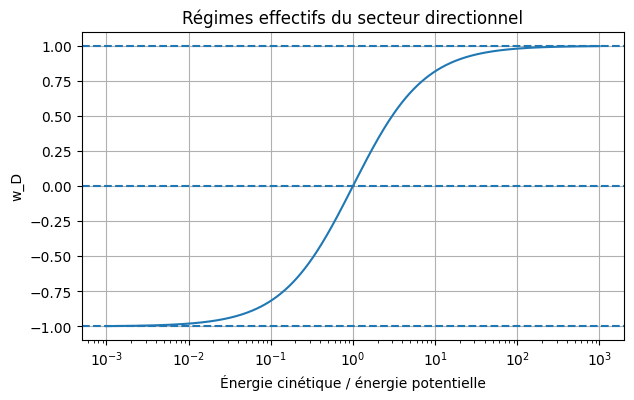

In [18]:

ratio = np.logspace(-3,3,500)

# r = énergie cinétique / énergie potentielle
w_ratio = (ratio-1)/(ratio+1)

plt.figure(figsize=(7,4))
plt.semilogx(ratio,w_ratio)
plt.axhline(-1,linestyle="--")
plt.axhline(0,linestyle="--")
plt.axhline(1,linestyle="--")
plt.xlabel("Énergie cinétique / énergie potentielle")
plt.ylabel("w_D")
plt.title("Régimes effectifs du secteur directionnel")
plt.grid(True)
plt.show()



# 18. Contraintes de quantité de mouvement

Dans la théorie ADM complète, la variation par rapport au shift \(N^i\) donne :

\[
\mathcal H_i^{\mathrm{GR}}
+
\mathcal H_i^D
\approx0.
\]

Dans la réduction homogène avec shift nul et champs homogènes :

\[
\mathcal H_i^D=0.
\]

Le notebook ne calcule donc pas encore la contrainte locale complète de quantité de mouvement.


In [19]:

momentum_constraint_status = pd.DataFrame([
    {
        "sector": "homogeneous minisuperspace",
        "H_i_D": 0,
        "status": "trivial"
    },
    {
        "sector": "inhomogeneous full theory",
        "H_i_D": "requires spatial derivatives and shift variation",
        "status": "not yet derived"
    }
])

momentum_constraint_status


,sector,H_i_D,status
0,homogeneous minisuperspace,0,trivial
1,inhomogeneous full theory,requires spatial derivatives and shift variation,not yet derived



# 19. Couplages non minimaux candidats

Une extension future pourrait ajouter :

\[
\lambda_K
\bar D_{ij}K^i{}_kK^{kj},
\]

\[
\lambda_R
\bar D_{ij}{}^{(3)}R^{ij},
\]

\[
\lambda_{KD}
K_{ij}\mathcal L_n\bar D^{ij}.
\]

Ces termes peuvent :

- modifier les moments conjugués ;
- mélanger les vitesses de \(\gamma_{ij}\) et \(D_{ij}\) ;
- rendre la hessienne dégénérée ;
- créer ou retirer des degrés de liberté ;
- introduire des ghosts.

Ils ne sont pas activés dans le modèle de base.


In [20]:

nonminimal_terms = pd.DataFrame([
    {
        "coupling": "lambda_K Dbar_ij K^i_k K^kj",
        "risk": "metric-directional kinetic mixing",
        "status": "CHECK"
    },
    {
        "coupling": "lambda_R Dbar_ij R3^ij",
        "risk": "spatial higher structure",
        "status": "CHECK"
    },
    {
        "coupling": "lambda_KD K_ij Lie_n(Dbar^ij)",
        "risk": "mixed kinetic Hessian",
        "status": "HIGH-PRIORITY CHECK"
    }
])

nonminimal_terms


,coupling,risk,status
0,lambda_K Dbar_ij K^i_k K^kj,metric-directional kinetic mixing,CHECK
1,lambda_R Dbar_ij R3^ij,spatial higher structure,CHECK
2,lambda_KD K_ij Lie_n(Dbar^ij),mixed kinetic Hessian,HIGH-PRIORITY CHECK



# 20. Hessienne cinétique du modèle isotrope couplé

Les variables dynamiques réduites sont :

\[
Q^A=(a,q_1,\dots,q_5,N).
\]

Le lapse n'a pas de vitesse, donc la hessienne possède au moins une direction nulle.

Pour :

\[
K_D\neq0,
\qquad
a>0,
\qquad
N\neq0,
\]

le secteur \((a,q_A)\) reste normalement inversible.


In [21]:

coordinates_reduced = [a] + q + [N_t]
velocities_reduced = [
    sp.diff(coord,t)
    for coord in coordinates_reduced
]

Hessian_reduced = sp.Matrix([
    [
        sp.simplify(
            sp.diff(
                sp.diff(
                    L_total_iso,
                    vi
                ),
                vj
            )
        )
        for vj in velocities_reduced
    ]
    for vi in velocities_reduced
])

print("Hessienne réduite :")
display(Hessian_reduced)

print("Dernière ligne (lapse) :")
display(Hessian_reduced[-1,:])


Hessienne réduite :


⎡           _______                                                            ↪
⎢      2   ╱  6                                                                ↪
⎢-6⋅Mpl ⋅╲╱  a (t)                                                             ↪
⎢───────────────────         0                 0                 0             ↪
⎢          2                                                                   ↪
⎢    N(t)⋅a (t)                                                                ↪
⎢                                                                              ↪
⎢                              _______                                         ↪
⎢                             ╱  6                                             ↪
⎢                     2⋅K_D⋅╲╱  a (t)                                          ↪
⎢         0           ────────────────         0                 0             ↪
⎢                           N(t)                                               ↪
⎢                           

Dernière ligne (lapse) :


[0  0  0  0  0  0  0]


# 21. Rang et comptage provisoire

Le minisuperspace contient :

- \(a\) : une variable métrique ;
- \(q_A\) : cinq variables directionnelles ;
- \(N\) : un multiplicateur.

Soit sept coordonnées de configuration.

Le lapse produit :

- une contrainte primaire \(p_N\approx0\) ;
- une contrainte hamiltonienne secondaire.

Cette paire est typiquement de première classe dans un système invariant par reparamétrisation temporelle.

Le comptage réduit donne alors :

\[
N_{\mathrm{DOF}}
=
7-2
=
5.
\]

Cela correspond à six variables dynamiques \((a,q_A)\), moins une redondance temporelle.

Ce résultat ne doit pas être confondu avec le comptage local complet de la relativité générale, qui possède deux modes métriques tensoriels.


In [22]:

dof_minisuperspace = pd.DataFrame([
    {
        "configuration_variables": 7,
        "first_class_constraints": 2,
        "second_class_constraints": 0,
        "DOF": 7-2,
        "interpretation": (
            "reduced homogeneous model only"
        )
    }
])

dof_minisuperspace


,configuration_variables,first_class_constraints,second_class_constraints,DOF,interpretation
0,7,2,0,5,reduced homogeneous model only



# 22. Comptage attendu dans une théorie locale complète

Avant contraintes, une décomposition candidate peut contenir :

- \(\gamma_{ij}\) : 6 composantes ;
- \(N\) : 1 ;
- \(N^i\) : 3 ;
- \(\bar D_{ij}\) : 5 ;
- éventuellement \(\Phi_D\) : 1 ;
- éventuellement \(V_i\) : 3.

Le nombre physique final dépend de :

- la symétrie de difféomorphisme ;
- la présence ou non d'une jauge propre à \(D_{\mu\nu}\) ;
- la nature dynamique de \(\Phi_D,V_i\) ;
- les contraintes secondaires ;
- les couplages non minimaux.

Aucun nombre définitif ne peut encore être annoncé.


In [23]:

full_component_inventory = pd.DataFrame([
    {"variable":"gamma_ij","components":6,"current_role":"metric dynamic"},
    {"variable":"N","components":1,"current_role":"multiplier"},
    {"variable":"N^i","components":3,"current_role":"multipliers"},
    {"variable":"Dbar_ij","components":5,"current_role":"candidate dynamic"},
    {"variable":"Phi_D","components":1,"current_role":"undetermined"},
    {"variable":"V_i","components":3,"current_role":"undetermined"}
])

full_component_inventory


,variable,components,current_role
0,gamma_ij,6,metric dynamic
1,N,1,multiplier
2,N^i,3,multipliers
3,Dbar_ij,5,candidate dynamic
4,Phi_D,1,undetermined
5,V_i,3,undetermined



# 23. Limite d'Einstein

La limite d'Einstein doit être obtenue lorsque :

\[
\bar D_{ij}\rightarrow0,
\]

ou lorsque le secteur directionnel se découple :

\[
K_D,m_D,\lambda_i
\rightarrow0
\]

selon une limite physiquement cohérente.

Dans le modèle minimal :

\[
L_{\mathrm{tot}}
\big|_{\bar D=0}
=
L_{\mathrm{GR}}.
\]


In [24]:

zero_directional_subs = {}

for qi in q:
    zero_directional_subs[qi] = 0
    zero_directional_subs[sp.diff(qi,t)] = 0

Einstein_limit_residual = sp.simplify(
    L_total.subs(zero_directional_subs)
    - L_GR_hom
)

print("Résidu de la limite Einstein :")
display(Einstein_limit_residual)


Résidu de la limite Einstein :


0


# 24. Validation automatique


In [25]:

adm_inverse_ok = (
    inverse_residual == sp.zeros(4)
)

normal_ok = (
    sp.simplify(normal_norm+1) == 0
)

trace_ok = (
    sp.simplify(
        sp.trace(Dbar_orth)
    ) == 0
)

lapse_constraint_ok = (
    p_N == 0
)

einstein_limit_ok = (
    Einstein_limit_residual == 0
)

hessian_lapse_null_ok = all(
    sp.simplify(value) == 0
    for value in Hessian_reduced[-1,:]
)

validation_df = pd.DataFrame([
    {
        "test":"ADM inverse",
        "status":"PASS" if adm_inverse_ok else "FAIL"
    },
    {
        "test":"Unit normal",
        "status":"PASS" if normal_ok else "FAIL"
    },
    {
        "test":"Dbar traceless",
        "status":"PASS" if trace_ok else "FAIL"
    },
    {
        "test":"Primary lapse constraint",
        "status":"PASS" if lapse_constraint_ok else "FAIL"
    },
    {
        "test":"Einstein limit",
        "status":"PASS" if einstein_limit_ok else "FAIL"
    },
    {
        "test":"Lapse Hessian null direction",
        "status":"PASS" if hessian_lapse_null_ok else "FAIL"
    }
])

validation_df


,test,status
0,ADM inverse,PASS
1,Unit normal,PASS
2,Dbar traceless,PASS
3,Primary lapse constraint,PASS
4,Einstein limit,PASS
5,Lapse Hessian null direction,PASS


In [26]:

overall_status = (
    "PASS"
    if (validation_df["status"]=="PASS").all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :",overall_status)


STATUT DU NOTEBOOK : PASS



# 25. Export des résultats


In [27]:

import json
from pathlib import Path

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.14_Validation.csv",
    index=False
)

dof_minisuperspace.to_csv(
    "GVH_Diagonal_Cubic_0.2.14_Reduced_DOF.csv",
    index=False
)

decomposition_count.to_csv(
    "GVH_Diagonal_Cubic_0.2.14_D_Tensor_Decomposition.csv",
    index=False
)

nonminimal_terms.to_csv(
    "GVH_Diagonal_Cubic_0.2.14_Nonminimal_Couplings.csv",
    index=False
)

full_component_inventory.to_csv(
    "GVH_Diagonal_Cubic_0.2.14_Full_Component_Inventory.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "ADM_status":"minimal homogeneous coupling derived",
    "primary_constraint":"p_N = 0",
    "secondary_constraint":"Hamiltonian constraint from dL/dN = 0",
    "reduced_DOF":5,
    "full_local_DOF":"undetermined",
    "Einstein_limit":"verified when Dbar_ij = 0",
    "active_directional_sector":"spatial symmetric traceless 5-component field",
    "main_open_problem":(
        "full inhomogeneous ADM constraint algebra including shift and all D_mu_nu sectors"
    )
}

with open(
    "GVH_Diagonal_Cubic_0.2.14_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")


Exports terminés.



# 26. Conclusion scientifique

Cette version construit le premier couplage minimal explicite :

\[
\boxed{
S_{\mathrm{tot}}
=
S_{\mathrm{ADM}}[N,N^i,\gamma_{ij}]
+
S_D[N,\gamma_{ij},\bar D_{ij}]
}
\]

Elle établit dans le modèle homogène :

1. la métrique ADM et son inverse ;
2. la normale et le projecteur spatial ;
3. la courbure extrinsèque ;
4. l'action gravitationnelle réduite ;
5. la décomposition \(3+1\) de \(D_{\mu\nu}\) ;
6. le secteur dynamique \(\bar D_{ij}\) à cinq composantes ;
7. le moment primaire
   \[
   p_N=0;
   \]
8. la contrainte hamiltonienne commune ;
9. l'amortissement des modes directionnels par l'expansion ;
10. la limite d'Einstein lorsque
    \[
    \bar D_{ij}=0.
    \]

Le comptage homogène donne provisoirement :

\[
\boxed{
N_{\mathrm{DOF}}^{\mathrm{mini}}=5
}
\]

mais le nombre local complet reste indéterminé.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.15\_Inhomogeneous\_ADM\_Constraint\_Algebra.ipynb}
}
\]

Elle devra introduire :

- dépendance spatiale ;
- shift non nul ;
- dérivées covariantes spatiales ;
- contraintes locales \(\mathcal H(x)\) et \(\mathcal H_i(x)\) ;
- crochets de Poisson fonctionnels ;
- fermeture de l'algèbre des contraintes ;
- premier comptage local complet.
